# Bell State Generation on Noisy Quantum Hardware (NISQ)

This project constructs a modular Bell state generator in **Qiskit** and compares ideal statevector probability distributions against physical execution on an IBM Quantum Processor (QPU). 

### Prerequisites & Stack
* **Framework:** Qiskit v2.4.1 | Qiskit Runtime (`qiskit-ibm-runtime`)
* **Environment:** Python 3.14.4
* **Target Hardware:** `ibm_fez` (Superconducting Quantum Processor)

In [2]:
#importing the necessary classes and functions from the relevant libraries and packages

from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
import sympy as sp

### Step 1: Creating the Bell State Generator Function

This is a function to create any of the four Bell States:
* $|\Phi^+\rangle = \frac{1}{\sqrt{2}} (|00\rangle + |11\rangle)$
* $|\Phi^-\rangle = \frac{1}{\sqrt{2}} (|00\rangle - |11\rangle)$
* $|\Psi^+\rangle = \frac{1}{\sqrt{2}} (|01\rangle + |10\rangle)$
* $|\Psi^-\rangle = \frac{1}{\sqrt{2}} (|01\rangle - |10\rangle)$

In [3]:
def bell_state_generator(label):
    """
    Function to produce the relevant quantum circuit for the defined label, such as phi_plus, phi_minus, psi_plus, psi_minus
    Returns Quantum Circuit
    """

    qc = QuantumCircuit(2)

    if label == "phi_minus" or label == "psi_minus":
        qc.x(0)

    if label == "psi_plus" or label == "psi_minus":
        qc.x(1)

    qc.h(0)
    qc.cx(0,1)

    return qc

### Step 2: Let's create $|\Psi^+\rangle = \frac{1}{\sqrt{2}} (|01\rangle + |10\rangle)$

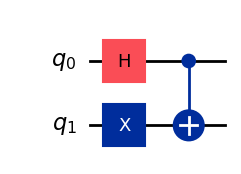

In [4]:
circuit = bell_state_generator("psi_plus")

display(circuit.draw('mpl'))

> **Circuit Logic Explanation:**  
> 1. **Initialization:** The $X$ gate applied to Qubit 1 ($q_1$) flips its state from $|0\rangle \rightarrow |1\rangle$, yielding initial state $|01\rangle$.  
> 2. **Superposition:** The Hadamard ($H$) gate on $q_0$ puts it into equal superposition $\frac{|0\rangle + |1\rangle}{\sqrt{2}}$.  
> 3. **Entanglement:** The $CNOT$ gate (control $q_0$, target $q_1$) entangles the pair:
>    * When $q_0 = 0 \implies q_1$ remains $1 \implies |01\rangle$
>    * When $q_0 = 1 \implies q_1$ flips $1 \rightarrow 0 \implies |10\rangle$
> 
> Resulting in the entangled Bell state: $|\Psi^+\rangle = \frac{|01\rangle + |10\rangle}{\sqrt{2}}$.

**Further Explanation:**

<small> So this circuit has a Hadamard operation on the first qubit (q0) to put it into superposition so that q0 exists in both 0 and 1. Why do we need that? Because then, when we bring in the Controlled-not (CNOT) gate, we'll get two possible states of the overall system and not just one (like {00}). The CNOT gate operates in a way that the control qubit is q0 and the target qubit is q1; hence, the 'fate' of q1 lies in the hands of q0:
* when q0 is 0, value of q1 remains unchanged
* when q1 is 1, the value of q1 flips (from 0 -> 1 or 1 -> 0)

However, with just the H and CNOT gates, the initial states of both qubits are 0 so we'll only get 00 (as when q0=0, q1 remains 0, i.e. unchanged) and 11 (as when q0=1, q1 flips from 0 to 1). Our state vector for psi_plus needs to have |01> and |10> where we see the state of q1 is reversed in both cases. Therefore, we need to apply the X gate to flip the initial state of q1 from 0 to 1.

In [5]:
statevector = Statevector(circuit)
display(statevector.draw("latex"))

<IPython.core.display.Latex object>

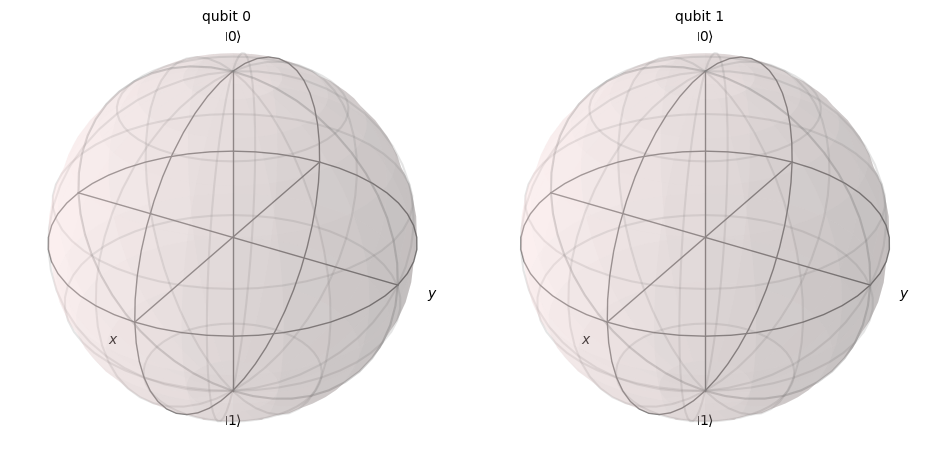

In [5]:
display(plot_bloch_multivector(statevector))

### Step 3: Measure the output of original circuit/statevector sampling

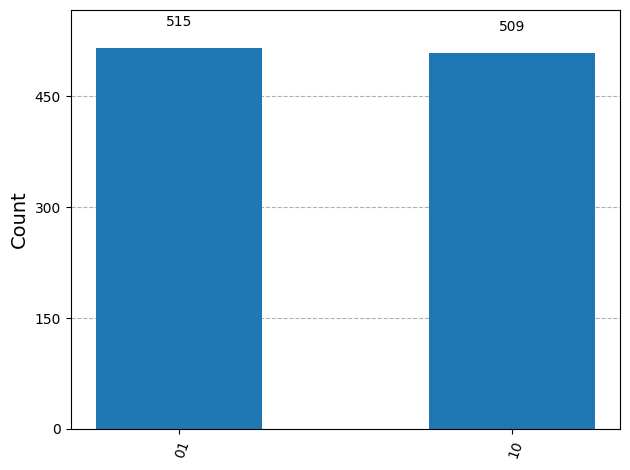

In [18]:
statistics = statevector.sample_counts(1024)
plot_histogram(statistics)

In [7]:
#Append measurements
qc_meas = circuit.copy()
qc_meas.measure_all()

### Step 4: Run the Bell State Circuit on Real Quantum Hardware

In [8]:
#Authenticate and select least-busy real quantum processor
service = QiskitRuntimeService()  # Account credentials saved beforehand
backend = service.least_busy(operational=True, simulator=False)

qiskit_runtime_service.__init__:WARNING:2026-08-23 00:17:59,007: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-08-23 00:17:59,596: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-08-23 00:18:03,480: Using instance: open-instance, plan: open


In [9]:
#Transpile the circuit for hardware topology
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
transpiled_qc = pm.run(qc_meas)

In [10]:
#Comparison of depths in transpiled circuit and abstract (original) circuit
print(f"Target QPU: {backend.name}")
print(f"Original Depth: {qc_meas.depth()} | Transpiled Depth: {transpiled_qc.depth()}")

Target QPU: ibm_fez
Original Depth: 3 | Transpiled Depth: 7


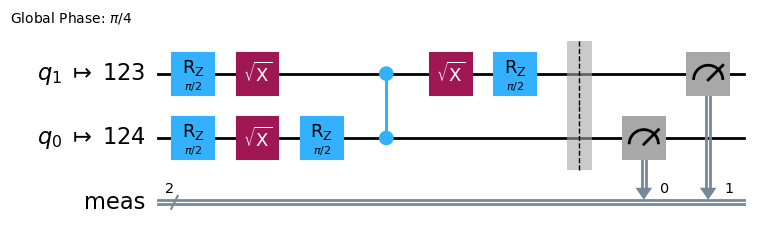

In [13]:
display(transpiled_qc.draw("mpl"))

> **Hardware Transpilation Analysis:**  
> Real quantum hardware (like `ibm_fez`) cannot execute abstract circuit gates directly. Transpilation translates standard operations into the QPU's specific native gates and routes them across physical qubit connections. This process adds extra gate layers, increasing overall circuit depth and giving physical noise more time to affect the results.

In [11]:
#Executing job on real quantum hardware and then retrieving the results in a noisy quantum hardware environment
sampler = Sampler(mode=backend)
job = sampler.run([transpiled_qc], shots=1024)
result = job.result()


counts = result[0].data.meas.get_counts()
print("Real Hardware Results:", counts)

Real Hardware Results: {'10': 490, '01': 503, '11': 10, '00': 21}


<small> We are getting the other two states (11 and 00) in the measurements which are not supposed to exist according to our construction of the circuit. However, we are getting these results in the real quantum hardware (ibm_fez in this case) due to the noise present as described above.

### Step 5: Compare Ideal Simulator vs. Real QPU Hardware Results

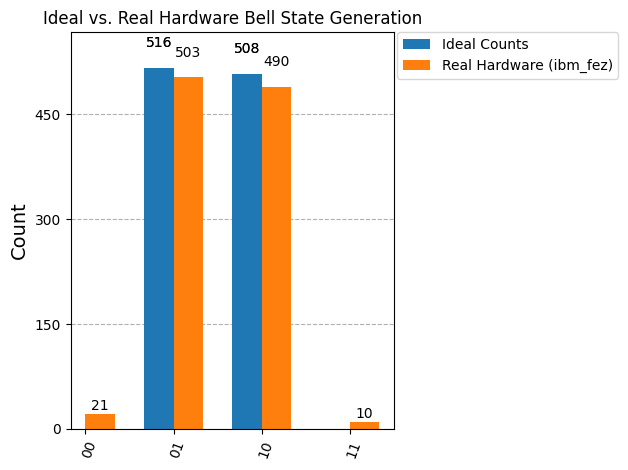

In [20]:
ideal_counts = {'01': 516, '10': 508}
real_hardware_counts = counts

# Plot both distributions on a single legend
plot_histogram(
    [ideal_counts, real_hardware_counts], 
    legend=['Ideal Counts', f'Real Hardware ({backend.name})'],
    title='Ideal vs. Real Hardware Bell State Generation'
)

<small> Executing on physical superconducting qubits introduces hardware-level decoherence and readout error as we can see by the introduction of 00 and 11 in the graph only for the hardware bell state generation.

### Step 6: Conclusion & Hardware Performance Takeaways

Executing the $|\Psi^+\rangle$ Bell state on **ibm_fez** confirms strong alignment with quantum theory while highlighting the impact of physical hardware noise:

#### 1. High Target Accuracy (~97%)
Out of 1,024 physical shots, **993 shots** generated the expected entangled states ($|01\rangle$ and $|10\rangle$):
* **$|01\rangle$:** 503 counts (~49.1%)
* **$|10\rangle$:** 490 counts (~47.9%)

This near-even split closely mirrors the theoretical 50/50 probability distribution calculated by ideal statevector sampling.

#### 2. Physical Hardware Noise
The remaining **31 counts** (~3.0% error rate across $|00\rangle$ and $|11\rangle$) are unexpected outcomes caused by QPU imperfections:
* **Gate Inaccuracies:** Physical control signals (laser/microwave pulses) are not 100% precise, leading to small gate execution errors.
* **Measurement Readout Errors:** Hardware sensors occasionally misread a physical qubit's final state during measurement.
* **Environmental Noise:** External interference during execution can cause qubits to lose their quantum state before the circuit finishes running.

#### 3. Transpilation & Optimization
While ideal statevector simulation produces a clean mathematical output, running on physical hardware introduces real-world noise. Using Qiskit's transpiler helped optimize the circuit layout, keeping gate depth low and ensuring high state fidelity on modern quantum hardware.